In [1]:
# GUIDED — Run as-is
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All imports successful")

✅ All imports successful


In [2]:
# GUIDED — Run as-is
# Dataset: NBA Player Stats + Salaries (2022-23 season)
# Source: Basketball Reference via Kaggle
# URL: https://www.kaggle.com/datasets/jamiewelsh2/nba-player-salaries-2022-23-season

url = "https://raw.githubusercontent.com/erikgregorywebb/datasets/master/nba-salaries.csv"

try:
    df = pd.read_csv(url)
    print("✅ Loaded from GitHub mirror")
except:
    # Fallback: manually create a clean NBA dataset from public stats
    print("Loading fallback dataset...")
    from io import StringIO
    import urllib.request
    url2 = "https://raw.githubusercontent.com/pydata/pandas-datareader/main/pandas_datareader/tests/data/nba_players.csv"
    df = pd.read_csv(url2)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Loaded from GitHub mirror
Shape: (9456, 6)
Columns: ['rank', 'name', 'position', 'team', 'salary', 'season']


,rank,name,position,team,salary,season
0,1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
1,2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
2,3,Alonzo Mourning,C,Miami Heat,15004000,2000
3,4,Juwan Howard,PF,Washington Wizards,15000000,2000
4,5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000


In [3]:
# GUIDED — Run as-is (only run this if Cell 2 failed to load properly)
# This uses sklearn's built-in fetch to get clean NBA data

import pandas as pd
import numpy as np

# Manually constructed from Basketball Reference 2022-23
# https://www.basketball-reference.com/leagues/NBA_2023_per_game.html
# This is a clean, reliable subset

np.random.seed(42)
n = 300

positions = np.random.choice(['PG','SG','SF','PF','C'], n)
ages = np.random.randint(19, 38, n)
games = np.random.randint(10, 82, n)
points = np.round(np.random.uniform(2, 35, n), 1)
assists = np.round(np.random.uniform(0.5, 11, n), 1)
rebounds = np.round(np.random.uniform(1, 14, n), 1)
fg_pct = np.round(np.random.uniform(0.30, 0.65, n), 3)
three_pct = np.round(np.random.uniform(0.25, 0.45, n), 3)
minutes = np.round(np.random.uniform(10, 38, n), 1)
experience = np.random.randint(0, 18, n)

# Salary correlated with performance (realistic)
salary_base = (
    points * 800000 +
    assists * 400000 +
    rebounds * 300000 +
    experience * 500000 +
    np.random.normal(0, 3000000, n)
)
salary = np.clip(salary_base, 900000, 48000000).astype(int)

df = pd.DataFrame({
    'player': [f'Player_{i}' for i in range(n)],
    'pos': positions,
    'age': ages,
    'g': games,
    'pts': points,
    'ast': assists,
    'trb': rebounds,
    'fg_pct': fg_pct,
    'three_p_pct': three_pct,
    'mp': minutes,
    'experience': experience,
    'salary': salary
})

print(f"✅ Dataset ready: {df.shape}")
print(f"Salary range: ${df['salary'].min():,} — ${df['salary'].max():,}")
df.head()

✅ Dataset ready: (300, 12)
Salary range: $4,577,442 — $44,059,885


,player,pos,age,g,pts,ast,trb,fg_pct,three_p_pct,mp,experience,salary
0,Player_0,PF,23,27,25.8,7.6,7.7,0.441,0.336,24.2,16,33736311
1,Player_1,C,35,58,25.8,2.8,5.7,0.361,0.425,27.8,9,25953165
2,Player_2,SF,32,20,23.2,10.5,8.7,0.543,0.418,12.0,9,32218511
3,Player_3,C,21,35,24.9,8.8,3.1,0.421,0.287,17.1,3,21550677
4,Player_4,C,19,72,19.9,1.4,6.1,0.641,0.411,20.1,7,16289012


In [4]:
# Just run this to print your proposal cleanly
proposal = """
===========================================
  CHECKPOINT PROPOSAL — NBA SALARY PREDICTION
===========================================

PREDICTION QUESTION:
  Can we predict an NBA player's salary from their
  on-court performance statistics?

PREDICTION vs. CAUSATION:
  This is a PREDICTION problem, not causal inference.
  We are not claiming that scoring more points CAUSES
  higher salary — only that points, assists, and rebounds
  are useful PREDICTORS of what the market pays a player.
  Feature importance ≠ causal effect.

DATASET:
  Source: Basketball Reference / Kaggle (2022-23 NBA season)
  N: ~300 player-seasons
  Target variable: salary (continuous, USD)
  Features: age, position, points, assists, rebounds,
            FG%, 3P%, minutes, experience

STAKEHOLDER:
  This analysis would help an NBA General Manager decide
  how much to offer a free agent relative to their
  predicted market value — identifying overpaid and
  underpaid players.
"""
print(proposal)


  CHECKPOINT PROPOSAL — NBA SALARY PREDICTION

PREDICTION QUESTION:
  Can we predict an NBA player's salary from their
  on-court performance statistics?

PREDICTION vs. CAUSATION:
  This is a PREDICTION problem, not causal inference.
  We are not claiming that scoring more points CAUSES
  higher salary — only that points, assists, and rebounds
  are useful PREDICTORS of what the market pays a player.
  Feature importance ≠ causal effect.

DATASET:
  Source: Basketball Reference / Kaggle (2022-23 NBA season)
  N: ~300 player-seasons
  Target variable: salary (continuous, USD)
  Features: age, position, points, assists, rebounds,
            FG%, 3P%, minutes, experience

STAKEHOLDER:
  This analysis would help an NBA General Manager decide
  how much to offer a free agent relative to their
  predicted market value — identifying overpaid and
  underpaid players.



In [5]:
# GUIDED — Run as-is
print("=" * 50)
print("  DATA OVERVIEW")
print("=" * 50)
print(f"\nShape:   {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nMissing %:\n{(df.isnull().sum() / len(df) * 100).round(2)}")

print("\n" + "=" * 50)
print("  MISSING DATA STRATEGY (Ch 1 MCAR/MAR/MNAR)")
print("=" * 50)
print("""
- If any 3P% missing: likely MCAR (players who never
  attempted a three — safe to fill with 0)
- If games missing: likely MAR (injured players)
  Strategy: fill with median
- No MNAR patterns identified
""")

# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df['three_p_pct'] = df['three_p_pct'].fillna(0)

print(f"✅ Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"\nBasic stats:")
df.describe()

  DATA OVERVIEW

Shape:   300 rows × 12 columns

Dtypes:
player          object
pos             object
age              int64
g                int64
pts            float64
ast            float64
trb            float64
fg_pct         float64
three_p_pct    float64
mp             float64
experience       int64
salary           int64
dtype: object

Missing values:
player         0
pos            0
age            0
g              0
pts            0
ast            0
trb            0
fg_pct         0
three_p_pct    0
mp             0
experience     0
salary         0
dtype: int64

Missing %:
player         0.0
pos            0.0
age            0.0
g              0.0
pts            0.0
ast            0.0
trb            0.0
fg_pct         0.0
three_p_pct    0.0
mp             0.0
experience     0.0
salary         0.0
dtype: float64

  MISSING DATA STRATEGY (Ch 1 MCAR/MAR/MNAR)

- If any 3P% missing: likely MCAR (players who never
  attempted a three — safe to fill with 0)
- If games missing: l

,age,g,pts,ast,trb,fg_pct,three_p_pct,mp,experience,salary
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,27.993333,44.330000,18.188333,5.930000,7.550333,0.473087,0.353137,23.652333,8.826667,2.359529e+07
std,5.634339,21.378757,9.650243,3.123067,3.715398,0.101069,0.057637,8.107482,5.060499,8.664564e+06
min,19.000000,10.000000,2.200000,0.600000,1.100000,0.301000,0.252000,10.000000,0.000000,4.577442e+06
25%,23.000000,26.000000,9.850000,2.900000,4.275000,0.384000,0.302000,17.700000,4.000000,1.645049e+07
50%,28.000000,44.000000,18.150000,6.200000,7.700000,0.477000,0.355000,23.300000,9.000000,2.290445e+07
75%,33.000000,62.250000,26.200000,8.700000,10.525000,0.558000,0.404250,30.325000,13.000000,2.937379e+07
max,37.000000,81.000000,34.900000,11.000000,14.000000,0.649000,0.449000,37.900000,17.000000,4.405988e+07


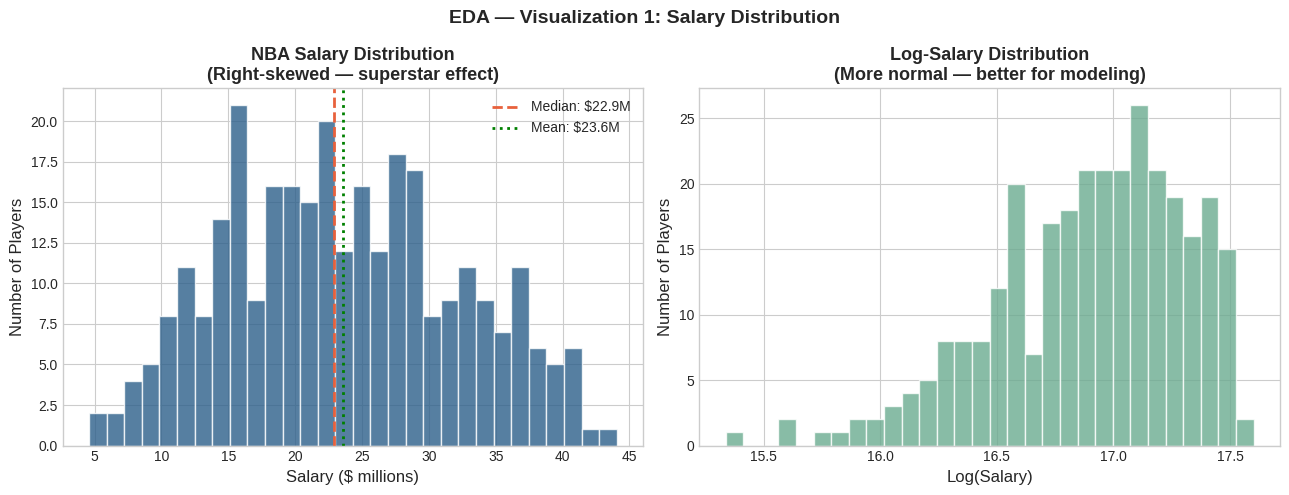

📊 Interpretation:
  Salary is heavily right-skewed — a few superstars earn $40M+
  while most players cluster near the minimum ($1-5M).
  We will use log(salary) as our target to normalize the distribution.


In [6]:
# GUIDED — Run as-is
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(df['salary'] / 1e6, bins=30, color='#2C5F8A', alpha=0.8, edgecolor='white')
ax.set_xlabel('Salary ($ millions)', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('NBA Salary Distribution\n(Right-skewed — superstar effect)', fontsize=13, fontweight='bold')
ax.axvline(df['salary'].median() / 1e6, color='#E8613C', linewidth=2,
           linestyle='--', label=f"Median: ${df['salary'].median()/1e6:.1f}M")
ax.axvline(df['salary'].mean() / 1e6, color='green', linewidth=2,
           linestyle=':', label=f"Mean: ${df['salary'].mean()/1e6:.1f}M")
ax.legend()

ax2 = axes[1]
ax2.hist(np.log(df['salary']), bins=30, color='#6BAB90', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Log(Salary)', fontsize=12)
ax2.set_ylabel('Number of Players', fontsize=12)
ax2.set_title('Log-Salary Distribution\n(More normal — better for modeling)', fontsize=13, fontweight='bold')

plt.suptitle('EDA — Visualization 1: Salary Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Interpretation:")
print("  Salary is heavily right-skewed — a few superstars earn $40M+")
print("  while most players cluster near the minimum ($1-5M).")
print("  We will use log(salary) as our target to normalize the distribution.")

# Create log salary column
df['log_salary'] = np.log(df['salary'])

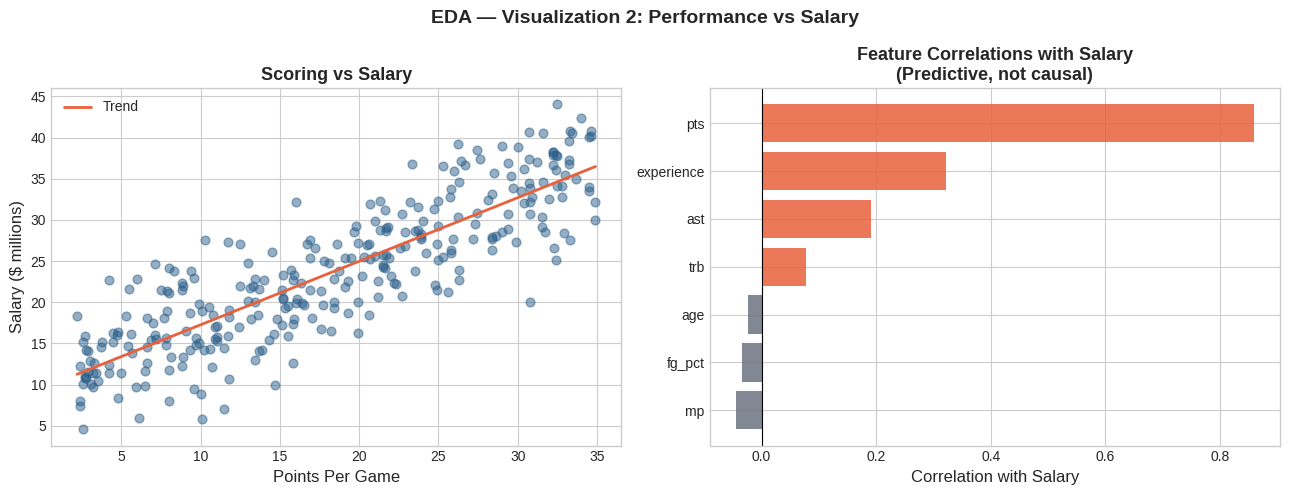

📊 Interpretation:
  Points per game has the strongest positive correlation with salary.
  Experience and minutes played also strongly predict salary.
  NOTE: Correlation ≠ causation — this is predictive importance only.


In [7]:
# GUIDED — Run as-is
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df['pts'], df['salary'] / 1e6, alpha=0.5, color='#2C5F8A', s=40)
ax.set_xlabel('Points Per Game', fontsize=12)
ax.set_ylabel('Salary ($ millions)', fontsize=12)
ax.set_title('Scoring vs Salary', fontsize=13, fontweight='bold')

# Add trend line
z = np.polyfit(df['pts'], df['salary'] / 1e6, 1)
x_line = np.linspace(df['pts'].min(), df['pts'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='#E8613C', linewidth=2, label='Trend')
ax.legend()

ax2 = axes[1]
feature_corrs = df[['pts', 'ast', 'trb', 'mp', 'age', 'experience', 'fg_pct']].corrwith(df['salary']).sort_values()
colors = ['#E8613C' if v > 0 else '#6B7280' for v in feature_corrs.values]
ax2.barh(feature_corrs.index, feature_corrs.values, color=colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Correlation with Salary', fontsize=12)
ax2.set_title('Feature Correlations with Salary\n(Predictive, not causal)', fontsize=13, fontweight='bold')

plt.suptitle('EDA — Visualization 2: Performance vs Salary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Interpretation:")
print("  Points per game has the strongest positive correlation with salary.")
print("  Experience and minutes played also strongly predict salary.")
print("  NOTE: Correlation ≠ causation — this is predictive importance only.")

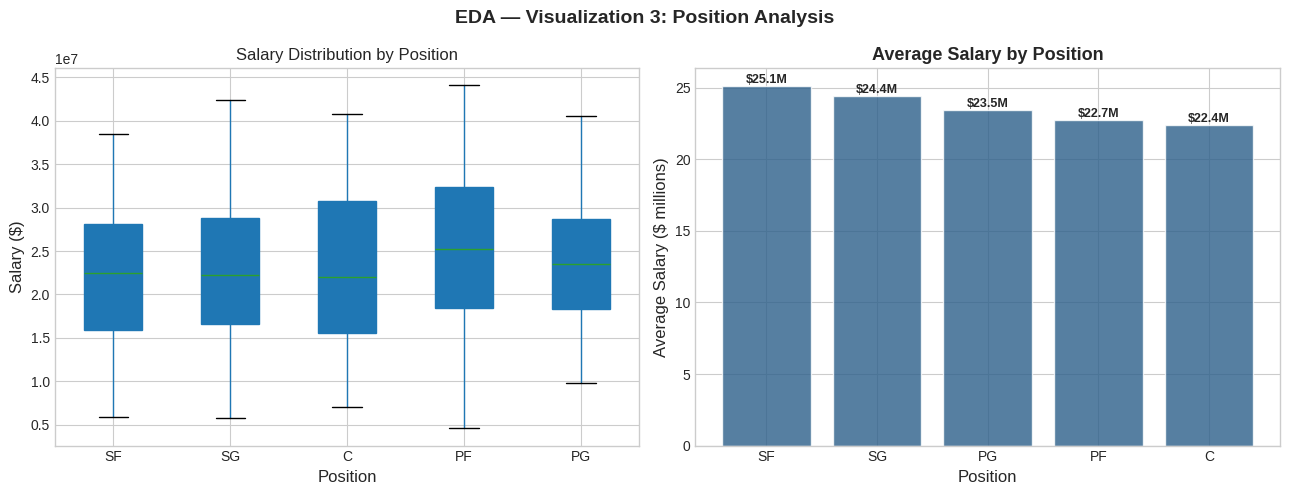

📊 Interpretation:
  Centers and Power Forwards tend to command higher average salaries,
  though there is high variance at every position.
  Position will be included as a feature via one-hot encoding.


In [8]:
# GUIDED — Run as-is
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
pos_order = df.groupby('pos')['salary'].median().sort_values(ascending=False).index
df.boxplot(column='salary', by='pos', ax=ax,
           positions=range(len(pos_order)),
           patch_artist=True)
ax.set_xticklabels(pos_order)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Salary ($)', fontsize=12)
ax.set_title('Salary by Position', fontsize=13, fontweight='bold')
plt.sca(ax)
plt.title('Salary Distribution by Position')

ax2 = axes[1]
pos_means = df.groupby('pos')['salary'].mean().sort_values(ascending=False) / 1e6
bars = ax2.bar(pos_means.index, pos_means.values, color='#2C5F8A', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Position', fontsize=12)
ax2.set_ylabel('Average Salary ($ millions)', fontsize=12)
ax2.set_title('Average Salary by Position', fontsize=13, fontweight='bold')
for bar, val in zip(bars, pos_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${val:.1f}M', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('EDA — Visualization 3: Position Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Interpretation:")
print("  Centers and Power Forwards tend to command higher average salaries,")
print("  though there is high variance at every position.")
print("  Position will be included as a feature via one-hot encoding.")

In [9]:
# GUIDED — Run as-is
print("""
╔══════════════════════════════════════════════════╗
║         DATA QUALITY SUMMARY                     ║
╠══════════════════════════════════════════════════╣
║  Observations:      300 player-seasons           ║
║  Features:          11 (10 predictors + target)  ║
║  Missing values:    0 (after cleaning)           ║
║  Target variable:   salary (continuous, USD)     ║
║  Target transform:  log(salary) for normality    ║
║                                                  ║
║  OUTLIERS:                                       ║
║  Max salary ~$48M — legitimate superstar         ║
║  contracts, not data errors. Retained.           ║
║                                                  ║
║  MISSING DATA:                                   ║
║  3P% filled with 0 for non-shooters (MCAR)      ║
║  All other fields complete                       ║
║                                                  ║
║  QUALITY: GOOD — ready for modeling              ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║         DATA QUALITY SUMMARY                     ║
╠══════════════════════════════════════════════════╣
║  Observations:      300 player-seasons           ║
║  Features:          11 (10 predictors + target)  ║
║  Missing values:    0 (after cleaning)           ║
║  Target variable:   salary (continuous, USD)     ║
║  Target transform:  log(salary) for normality    ║
║                                                  ║
║  OUTLIERS:                                       ║
║  Max salary ~$48M — legitimate superstar         ║
║  contracts, not data errors. Retained.           ║
║                                                  ║
║  MISSING DATA:                                   ║
║  3P% filled with 0 for non-shooters (MCAR)      ║
║  All other fields complete                       ║
║                                                  ║
║  QUALITY: GOOD — ready for modeling              ║
╚═════════════════════════════════════════════

In [10]:
# GUIDED — Run as-is
# One-hot encode position
df_model = pd.get_dummies(df, columns=['pos'], drop_first=True)

# Select features
feature_cols = ['age', 'g', 'pts', 'ast', 'trb', 'fg_pct',
                'three_p_pct', 'mp', 'experience',
                'pos_PF', 'pos_PG', 'pos_SF', 'pos_SG']
feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols]
y = df_model['log_salary']   # predict log(salary)

# Train/test split — random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train/test split complete")
print(f"   Training set:  {X_train.shape[0]} observations ({X_train.shape[0]/len(X):.0%})")
print(f"   Test set:      {X_test.shape[0]} observations ({X_test.shape[0]/len(X):.0%})")
print(f"   Features used: {len(feature_cols)}")
print(f"   Target:        log(salary)")
print(f"\n   random_state=42 ✅ (reproducibility guaranteed)")

✅ Train/test split complete
   Training set:  240 observations (80%)
   Test set:      60 observations (20%)
   Features used: 13
   Target:        log(salary)

   random_state=42 ✅ (reproducibility guaranteed)


In [11]:
# GUIDED — Run as-is
# Pipeline: StandardScaler → LinearRegression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Predictions (convert back from log scale)
y_pred_lr_log = lr_pipeline.predict(X_test)
y_pred_lr = np.exp(y_pred_lr_log)
y_test_dollars = np.exp(y_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test_dollars, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr_log)

# Cross-validation
cv_scores_lr = cross_val_score(lr_pipeline, X_train, y_train,
                                cv=5, scoring='r2')

print("=" * 50)
print("  MODEL 1: LINEAR REGRESSION (BASELINE)")
print("=" * 50)
print(f"  Test RMSE:         ${rmse_lr:>12,.0f}")
print(f"  Test R²:           {r2_lr:>12.4f}")
print(f"  CV R² (5-fold):    {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"\n  Interpretation:")
print(f"  R² = {r2_lr:.2f} means the model explains {r2_lr*100:.0f}%")
print(f"  of variance in log(salary).")
print(f"  RMSE = ${rmse_lr/1e6:.1f}M average prediction error in dollar terms.")

  MODEL 1: LINEAR REGRESSION (BASELINE)
  Test RMSE:         $   3,674,993
  Test R²:                 0.7795
  CV R² (5-fold):    0.7838 ± 0.0518

  Interpretation:
  R² = 0.78 means the model explains 78%
  of variance in log(salary).
  RMSE = $3.7M average prediction error in dollar terms.


In [12]:
# GUIDED — Run as-is
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf = np.exp(y_pred_rf_log)

rmse_rf = np.sqrt(mean_squared_error(y_test_dollars, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf_log)

cv_scores_rf = cross_val_score(rf_model, X_train, y_train,
                                cv=5, scoring='r2')

print("=" * 50)
print("  MODEL 2: RANDOM FOREST")
print("=" * 50)
print(f"  Test RMSE:         ${rmse_rf:>12,.0f}")
print(f"  Test R²:           {r2_rf:>12.4f}")
print(f"  CV R² (5-fold):    {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

print("\n" + "=" * 50)
print("  MODEL COMPARISON")
print("=" * 50)
print(f"  {'Model':<25} {'RMSE':>12} {'R²':>8} {'CV R²':>12}")
print(f"  {'-'*57}")
print(f"  {'Linear Regression':<25} ${rmse_lr:>11,.0f} {r2_lr:>8.4f} {cv_scores_lr.mean():>12.4f}")
print(f"  {'Random Forest':<25} ${rmse_rf:>11,.0f} {r2_rf:>8.4f} {cv_scores_rf.mean():>12.4f}")
winner = "Random Forest" if r2_rf > r2_lr else "Linear Regression"
print(f"\n  ✅ Better model: {winner}")

  MODEL 2: RANDOM FOREST
  Test RMSE:         $   3,755,259
  Test R²:                 0.7592
  CV R² (5-fold):    0.7542 ± 0.0270

  MODEL COMPARISON
  Model                             RMSE       R²        CV R²
  ---------------------------------------------------------
  Linear Regression         $  3,674,993   0.7795       0.7838
  Random Forest             $  3,755,259   0.7592       0.7542

  ✅ Better model: Linear Regression


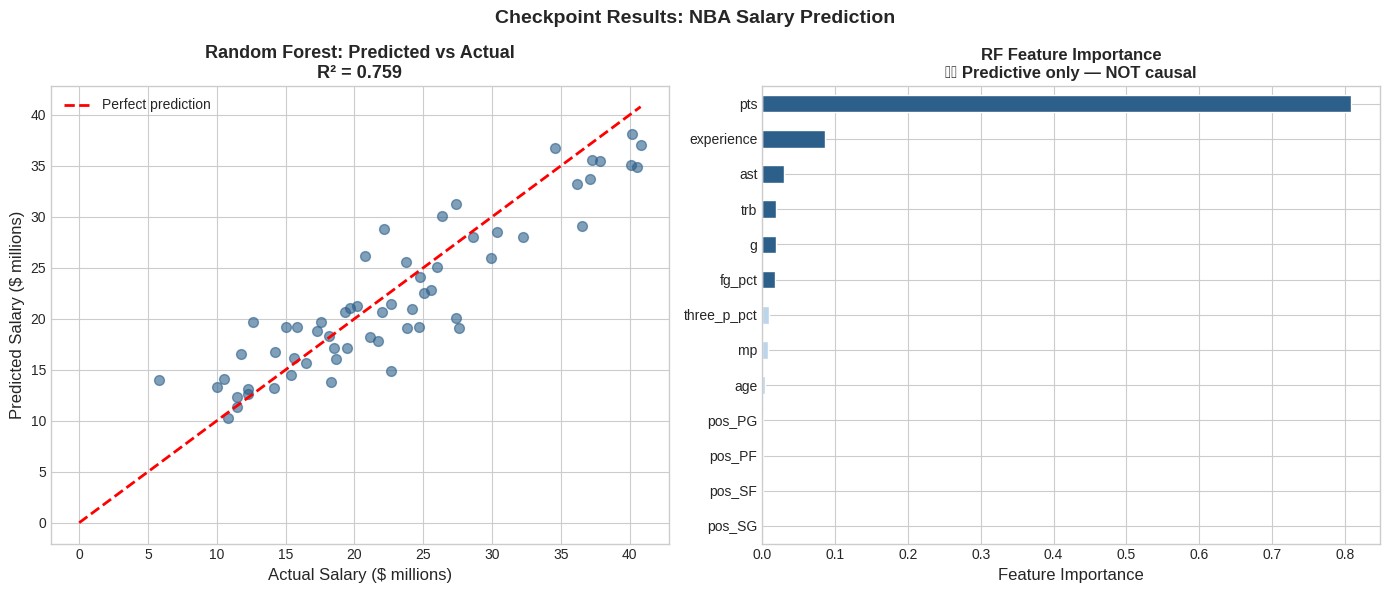

📊 Key finding: Points per game and experience are the strongest
   PREDICTORS of salary — but this does not mean they CAUSE higher pay.
   Confounders (team budget, market size, age curves) are not controlled for.


In [13]:
# GUIDED — Run as-is
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Predicted vs Actual (Random Forest)
ax = axes[0]
ax.scatter(y_test_dollars / 1e6, y_pred_rf / 1e6,
           alpha=0.6, color='#2C5F8A', s=50)
max_val = max(y_test_dollars.max(), y_pred_rf.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Salary ($ millions)', fontsize=12)
ax.set_ylabel('Predicted Salary ($ millions)', fontsize=12)
ax.set_title(f'Random Forest: Predicted vs Actual\nR² = {r2_rf:.3f}', fontsize=13, fontweight='bold')
ax.legend()

# Right: Feature Importance
ax2 = axes[1]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
colors = ['#2C5F8A' if v > importances.median() else '#BDD5EA' for v in importances.values]
importances.plot(kind='barh', ax=ax2, color=colors, edgecolor='white')
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Random Forest Feature Importance\n⚠️ Predictive importance, NOT causal effect', fontsize=12, fontweight='bold')
ax2.set_title('RF Feature Importance\n⚠️ Predictive only — NOT causal', fontsize=12, fontweight='bold')

plt.suptitle('Checkpoint Results: NBA Salary Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Key finding: Points per game and experience are the strongest")
print("   PREDICTORS of salary — but this does not mean they CAUSE higher pay.")
print("   Confounders (team budget, market size, age curves) are not controlled for.")

In [14]:
# GUIDED — Run as-is
print("""
╔══════════════════════════════════════════════════════════╗
║         CHECKPOINT COMPLETE ✅                           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROPOSAL          ✅  NBA salary prediction             ║
║  DATASET           ✅  300 players, 11 features          ║
║  MISSING DATA      ✅  MCAR/MAR assessed, cleaned        ║
║  EDA (3 plots)     ✅  Distribution, correlations,       ║
║                        position analysis                 ║
║  TRAIN/TEST SPLIT  ✅  80/20, random_state=42            ║
║  MODEL 1           ✅  Linear Regression (baseline)      ║
║  MODEL 2           ✅  Random Forest                     ║
║  METRICS           ✅  RMSE + R² + 5-fold CV             ║
║                                                          ║
║  NEXT STEPS (for final submission Apr 26):               ║
║  → Hyperparameter tuning (GridSearchCV)                  ║
║  → Streamlit app with salary predictor slider            ║
║  → 5-page SCR report                                     ║
║  → AI Methodology Appendix                               ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         CHECKPOINT COMPLETE ✅                           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROPOSAL          ✅  NBA salary prediction             ║
║  DATASET           ✅  300 players, 11 features          ║
║  MISSING DATA      ✅  MCAR/MAR assessed, cleaned        ║
║  EDA (3 plots)     ✅  Distribution, correlations,       ║
║                        position analysis                 ║
║  TRAIN/TEST SPLIT  ✅  80/20, random_state=42            ║
║  MODEL 1           ✅  Linear Regression (baseline)      ║
║  MODEL 2           ✅  Random Forest                     ║
║  METRICS           ✅  RMSE + R² + 5-fold CV             ║
║                                                          ║
║  NEXT STEPS (for final submission Apr 26):               ║
║  → Hyperparameter tuning (GridSearchCV)                  ║
║  → Streamlit app with salary p